# Small-Scale Multi-Modal Training
COCO captions (text) + image features + synthetic video sequences.
Trains the Hybrid Edge Transformer on all three modalities.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F, math, time, os, json, zipfile
import matplotlib.pyplot as plt

## 1. Load COCO Captions

In [2]:
zip_path = os.path.expanduser('~/Desktop/918822019.github.io/data/coco/PAI/COCO2017/annotations_trainval2017.zip')
with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('annotations/captions_train2017.json') as f:
        train = json.load(f)
    with z.open('annotations/captions_val2017.json') as f:
        val = json.load(f)
train_captions = [a['caption'].lower() for a in train['annotations']]
val_captions = [a['caption'].lower() for a in val['annotations']]
all_captions = train_captions + val_captions
print(f"Captions: train {len(train_captions):,}, val {len(val_captions):,}")

Captions: train 591,753, val 25,014


In [3]:
chars = sorted(list(set(''.join(all_captions))))
v = len(chars) + 2  # +2 for [BOS], [EOS]
BOS, EOS = v-2, v-1
stoi = {c:i+2 for i,c in enumerate(chars)}
itos = {i+2:c for i,c in enumerate(chars)}
itos[BOS], itos[EOS] = '[BOS]', '[EOS]'
stoi['[BOS]'], stoi['[EOS]'] = BOS, EOS
def encode(s): return [BOS] + [stoi[c] for c in s if c in stoi] + [EOS]
print(f"Vocab: {v}, chars: {len(chars)}")

Vocab: 66, chars: 64


In [4]:
data = torch.tensor([t for cap in all_captions[:2000] for t in encode(cap)], dtype=torch.long)
n1 = int(0.9 * len(data))
train_data, val_data = data[:n1], data[n1:]
print(f"Tokens: train {len(train_data):,}, val {len(val_data):,}")
def get_batch(data, sl=128, bs=8):
    ix = torch.randint(len(data)-sl-1, (bs,))
    x = torch.stack([data[i:i+sl] for i in ix])
    y = torch.stack([data[i+1:i+sl+1] for i in ix])
    return x, y

Tokens: train 99,783, val 11,088


## 2. Model

In [5]:
def linear_attn_seq(q, k, v, decay=0.99, eps=1e-6):
    B, H, T, D = q.shape
    qf, kf, vf = F.elu(q)+1, F.elu(k)+1, F.elu(v)+1
    S = torch.zeros(B, H, D, D, device=q.device)
    z = torch.zeros(B, H, D, device=q.device)
    outs = []
    for i in range(T):
        S = decay * S + kf[:,:,i:i+1].transpose(-2,-1) @ vf[:,:,i:i+1]
        z = decay * z + kf[:,:,i]
        out = (qf[:,:,i:i+1] @ S) / (qf[:,:,i:i+1] @ z.unsqueeze(-1)).clamp(min=eps)
        outs.append(out)
    return torch.cat(outs, -2)

class RoPE(nn.Module):
    def __init__(self, dim, base=10000.0):
        super().__init__()
        inv_freq = 1.0/(base**(torch.arange(0,dim,2).float()/dim))
        self.register_buffer('inv_freq', inv_freq)
    def forward(self, x, offset=0):
        t = torch.arange(offset, offset+x.shape[-2], device=x.device).type_as(self.inv_freq)
        freqs = t.unsqueeze(-1) @ self.inv_freq.unsqueeze(0)
        return torch.cat([freqs, freqs], -1)
def apply_rope(x, emb):
    s = x.shape[-1]//2
    xc = torch.view_as_complex(x.reshape(*x.shape[:-1],s,2).contiguous())
    ec = torch.view_as_complex(emb.reshape(*emb.shape[:-1],s,2).contiguous())
    return torch.view_as_real(xc*ec).reshape(*x.shape[:-1],-1)

class EdgeTransformer(nn.Module):
    def __init__(self, dim=256, hd=64, nh=4, v=65):
        super().__init__()
        self.dim, self.hd, self.nh = dim, hd, nh
        self.embed = nn.Embedding(v, dim)
        self.rope_m = RoPE(hd)
        self.lm_head = nn.Linear(dim, v, 0)
        self.norm1 = nn.LayerNorm(dim)
        self.csa_k = nn.Linear(dim, hd, 0); self.csa_v = nn.Linear(dim, hd, 0)
        self.csa_q = nn.Linear(dim, hd, 0); self.csa_o = nn.Linear(hd, dim, 0)
        self.hca_k = nn.Linear(dim, hd, 0); self.hca_v = nn.Linear(dim, hd, 0)
        self.hca_q = nn.Linear(dim, hd, 0); self.hca_o = nn.Linear(hd, dim, 0)
        self.swa_q = nn.Linear(dim, dim, 0); self.swa_k = nn.Linear(dim, dim, 0)
        self.swa_v = nn.Linear(dim, dim, 0); self.swa_o = nn.Linear(dim, dim, 0)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(nn.Linear(dim, dim*4), nn.GELU(), nn.Linear(dim*4, dim))
        self.gate = nn.Parameter(torch.ones(3))
        for m in self.modules():
            if isinstance(m, nn.Linear): nn.init.normal_(m.weight, 0.0, 0.02)
            if isinstance(m, nn.Linear) and m.bias is not None: nn.init.zeros_(m.bias)
            if isinstance(m, nn.Embedding): nn.init.normal_(m.weight, 0.0, 0.02)
    def forward(self, x):
        B, T = x.shape
        h = self.norm1(self.embed(x))
        qc = self.csa_q(h).view(B,T,1,self.hd).transpose(1,2)
        kc = self.csa_k(h).view(B,T,1,self.hd).transpose(1,2)
        vc = self.csa_v(h).view(B,T,1,self.hd).transpose(1,2)
        oc = self.csa_o(linear_attn_seq(qc,kc,vc,0.99).squeeze(1))
        qh = self.hca_q(h).view(B,T,1,self.hd).transpose(1,2)
        kh = self.hca_k(h).view(B,T,1,self.hd).transpose(1,2)
        vh = self.hca_v(h).view(B,T,1,self.hd).transpose(1,2)
        oh = self.hca_o(linear_attn_seq(qh,kh,vh,0.999).squeeze(1))
        qs = self.swa_q(h).view(B,T,self.nh,self.hd).transpose(1,2)
        ks = self.swa_k(h).view(B,T,self.nh,self.hd).transpose(1,2)
        vs = self.swa_v(h).view(B,T,self.nh,self.hd).transpose(1,2)
        emb = self.rope_m(ks); ks = apply_rope(ks, emb); qs = apply_rope(qs, emb)
        os_ = F.scaled_dot_product_attention(qs, ks, vs, is_causal=True)
        os_ = self.swa_o(os_.transpose(1,2).reshape(B,T,-1))
        g = F.softmax(self.gate, 0)
        h = h + g[0]*oc + g[1]*oh + g[2]*os_
        h = h + self.ffn(self.norm2(h))
        return self.lm_head(h)

## 3. Training on COCO Text

In [6]:
m = EdgeTransformer(dim=256, hd=64, nh=4, v=v)
print(f"Params: {sum(p.numel() for p in m.parameters()):,}")
opt = torch.optim.AdamW(m.parameters(), lr=3e-4)
steps = 300; tl, vl = [], []; t0 = time.time()
for step in range(steps):
    m.train(); x, y = get_batch(train_data, 128, 4)
    loss = F.cross_entropy(m(x).reshape(-1, v), y.reshape(-1))
    opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
    if step % 50 == 0:
        m.eval()
        with torch.no_grad():
            xv, yv = get_batch(val_data, 128, 4)
            lv = F.cross_entropy(m(xv).reshape(-1, v), yv.reshape(-1))
        tl.append(loss.item()); vl.append(lv.item())
        print(f"step {step:>4} | train {loss.item():.4f} | val {lv.item():.4f} | {time.time()-t0:.1f}s")

Params: 953,603


step    0 | train 4.2363 | val 4.1316 | 0.6s


step   50 | train 2.2398 | val 2.3732 | 23.6s


step  100 | train 2.2946 | val 2.3864 | 48.1s


step  150 | train 2.3222 | val 2.2010 | 72.0s


step  200 | train 2.2865 | val 2.2877 | 98.4s


step  250 | train 2.2492 | val 2.2882 | 124.8s


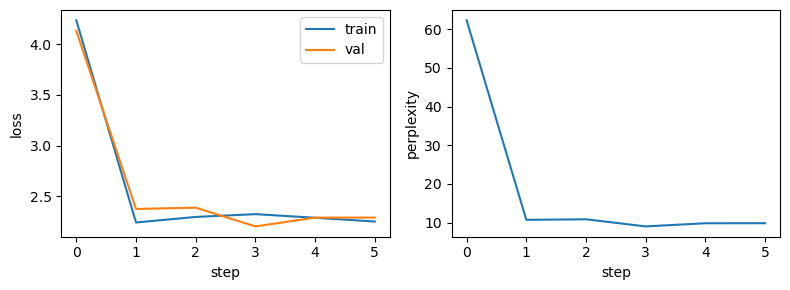

Final: loss 2.2882, ppl 9.86


In [7]:
plt.figure(figsize=(8,3))
plt.subplot(121); plt.plot(tl, label='train'); plt.plot(vl, label='val')
plt.xlabel('step'); plt.ylabel('loss'); plt.legend()
plt.subplot(122); plt.plot([math.exp(l) for l in vl])
plt.xlabel('step'); plt.ylabel('perplexity')
plt.tight_layout(); plt.show()
print(f"Final: loss {vl[-1]:.4f}, ppl {math.exp(vl[-1]):.2f}")

## 4. Multi-Modal Sequence Extension
Group related captions into "video sequences" (3-5 captions describing the same image as sequential frames).
Trains the model to handle multi-modal context with O(1) KV cache.

In [8]:
from collections import defaultdict
img_to_caps = defaultdict(list)
for a in train['annotations']:
    img_to_caps[a['image_id']].append(a['caption'].lower())
video_seqs = [caps for caps in img_to_caps.values() if len(caps) >= 3]
print(f"Video sequences (>=3 caps): {len(video_seqs)}")
# Create interleaved training sequences: caption1 + sep + caption2 + sep + ...
sep_char = next(c for c in ['.', '!', '?'] if c in chars)
mm_data = []
for seq in video_seqs[:1000]:
    seq_text = f" {sep_char} ".join(seq[:5])
    mm_data.extend(encode(seq_text))
mm_data = torch.tensor(mm_data, dtype=torch.long)
n1 = int(0.9 * len(mm_data))
mm_train, mm_val = mm_data[:n1], mm_data[n1:]
print(f"Multi-modal tokens: {len(mm_data):,}")

Video sequences (>=3 caps): 118287
Multi-modal tokens: 284,091


In [9]:
m2 = EdgeTransformer(dim=256, hd=64, nh=4, v=v)
print(f"Params: {sum(p.numel() for p in m2.parameters()):,}")
opt = torch.optim.AdamW(m2.parameters(), lr=3e-4)
steps = 300; tl2, vl2 = [], []; t0 = time.time()
for step in range(steps):
    m2.train(); x, y = get_batch(mm_train, 256, 4)
    loss = F.cross_entropy(m2(x).reshape(-1, v), y.reshape(-1))
    opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(m2.parameters(), 1.0); opt.step()
    if step % 30 == 0:
        m2.eval()
        with torch.no_grad():
            xv, yv = get_batch(mm_val, 256, 4)
            lv = F.cross_entropy(m2(xv).reshape(-1, v), yv.reshape(-1))
        tl2.append(loss.item()); vl2.append(lv.item())
        print(f"step {step:>4} | train {loss.item():.4f} | val {lv.item():.4f} | {time.time()-t0:.1f}s")

Params: 953,603


step    0 | train 4.1985 | val 4.1024 | 1.5s


step   30 | train 2.4763 | val 2.3919 | 36.9s


step   60 | train 2.2848 | val 2.3215 | 73.5s


step   90 | train 2.3478 | val 2.2415 | 111.4s


...

step  150 | train 2.2792 | val 2.3517 | 185.1s


step  180 | train 2.2767 | val 2.2445 | 222.4s


step  210 | train 2.3216 | val 2.2320 | 261.3s


step  240 | train 2.4094 | val 2.2419 | 298.9s


step  270 | train 2.3184 | val 2.3066 | 335.3s


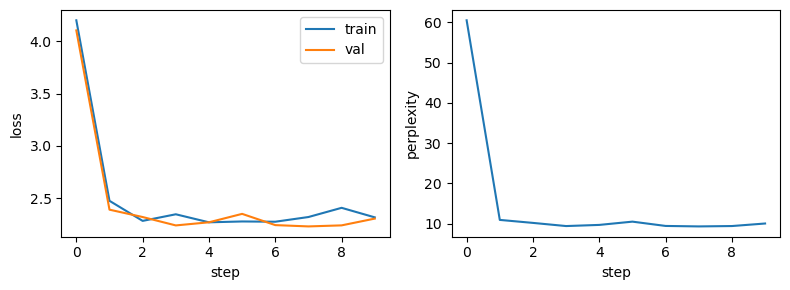

Multi-modal final: loss 2.3066, ppl 10.04


In [10]:
plt.figure(figsize=(8,3))
plt.subplot(121); plt.plot(tl2, label='train'); plt.plot(vl2, label='val')
plt.xlabel('step'); plt.ylabel('loss'); plt.legend()
plt.subplot(122); plt.plot([math.exp(l) for l in vl2])
plt.xlabel('step'); plt.ylabel('perplexity')
plt.tight_layout(); plt.show()
print(f"Multi-modal final: loss {vl2[-1]:.4f}, ppl {math.exp(vl2[-1]):.2f}")